<a href="https://colab.research.google.com/github/sindhura-nk/Machine-Learning-1491/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## K-Means Clustering

## Build a model that creates customer groups who are frequently visiting the mall on basis of Age,Income and Spending

In [1]:
path = r'https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/Mall_Customers.csv'
import pandas as pd
df = pd.read_csv(path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Perform basic data quality checks

In [2]:
df.shape

(200, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
## Duplicated rows
df.duplicated().sum()

np.int64(0)

In [6]:
df=df.drop_duplicates()

In [7]:
# Missing values
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Separate X features. Consider the features for which you want clusters to be formed.
You can perform EDA to decide which features to consider for cluster creation

In [8]:
X = df.drop(columns=['Gender','CustomerID'])
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [10]:
X.columns = ['Age','Income','Spending']
X.columns

Index(['Age', 'Income', 'Spending'], dtype='object')

## Data Cleaning and Preprocessing

In [11]:
X.dtypes

,0
Age,int64
Income,int64
Spending,int64


In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
).set_output(transform='pandas')

X_pre = num_pipe.fit_transform(X)
X_pre.head()

,Age,Income,Spending
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## Model Building

In [13]:
pip install yellowbrick

In [14]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import kelbow_visualizer

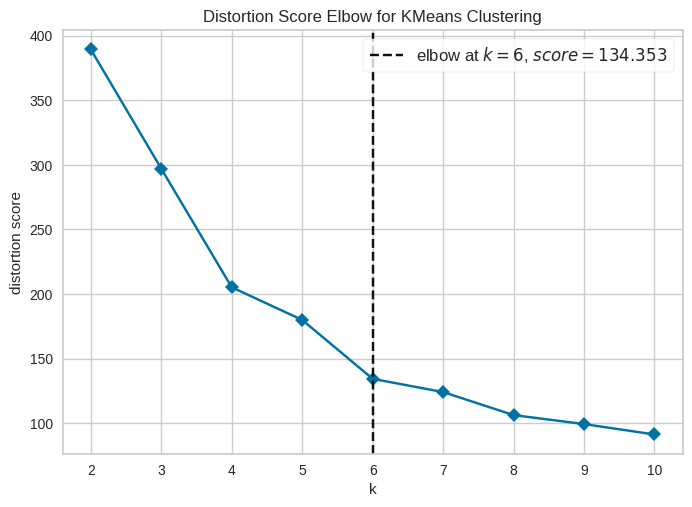

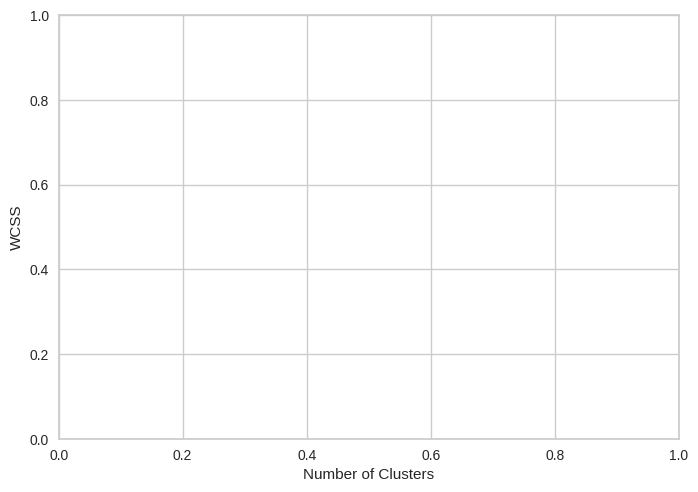

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [18]:
import matplotlib.pyplot as plt

base_model = KMeans()
visualizer = kelbow_visualizer(base_model,X_pre,k=(2,11),timings=False)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
visualizer.show()

In [19]:
## Build the model with K=6
final_model = KMeans(n_clusters=6) # k=n_clusters
clusters = final_model.fit_predict(X_pre) # cluster creation : 6 clusters , cluster information for each datapoint
clusters

array([0, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0,
       5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 3, 0, 5, 2,
       5, 0, 3, 2, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 2,
       3, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 2, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2,
       2, 3, 3, 2, 3, 2, 2, 2, 3, 2, 3, 2, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3,
       3, 2, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2, 2, 4, 2, 4, 1, 4, 1, 4, 1, 4,
       2, 4, 1, 4, 1, 4, 1, 4, 1, 4, 2, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 3, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

In [20]:
final_model.cluster_centers_

array([[-0.99396865, -1.34734766,  1.06404834],
       [ 0.17329545,  1.06645385, -1.2980103 ],
       [-0.85043527, -0.14894113, -0.04147777],
       [ 1.25472096, -0.24021294, -0.04399777],
       [-0.44191719,  0.99158305,  1.23950275],
       [ 0.47895722, -1.30822992, -1.19644353]])

In [21]:
X.head()

,Age,Income,Spending
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [22]:
X['Customer_Groups'] = clusters
X.head()

,Age,Income,Spending,Customer_Groups
0,19,15,39,0
1,21,15,81,0
2,20,16,6,5
3,23,16,77,0
4,31,17,40,5


In [24]:
fil1 = X['Customer_Groups']==0
X[fil1]

,Age,Income,Spending,Customer_Groups
0,19,15,39,0
1,21,15,81,0
3,23,16,77,0
5,22,17,76,0
7,23,18,94,0
9,30,19,72,0
11,35,19,99,0
13,24,20,77,0
15,22,20,79,0
17,20,21,66,0


In [25]:
for i in range(6):
  print(f'Cluster {i}')
  display(X[X['Customer_Groups']==i])
  print("===============")

Cluster 0


,Age,Income,Spending,Customer_Groups
0,19,15,39,0
1,21,15,81,0
3,23,16,77,0
5,22,17,76,0
7,23,18,94,0
9,30,19,72,0
11,35,19,99,0
13,24,20,77,0
15,22,20,79,0
17,20,21,66,0


Cluster 1


,Age,Income,Spending,Customer_Groups
126,43,71,35,1
128,59,71,11,1
130,47,71,9,1
134,20,73,5,1
136,44,73,7,1
138,19,74,10,1
140,57,75,5,1
144,25,77,12,1
146,48,77,36,1
148,34,78,22,1


Cluster 2


...

,Age,Income,Spending,Customer_Groups
40,65,38,35,3
46,50,40,55,3
50,49,42,52,3
53,59,43,60,3
54,50,43,45,3
55,47,43,41,3
56,51,44,50,3
57,69,44,46,3
59,53,46,46,3
60,70,46,56,3


Cluster 4


,Age,Income,Spending,Customer_Groups
123,39,69,91,4
125,31,70,77,4
127,40,71,95,4
129,38,71,75,4
131,39,71,75,4
133,31,72,71,4
135,29,73,88,4
137,32,73,73,4
139,35,74,72,4
141,32,75,93,4


Cluster 5


,Age,Income,Spending,Customer_Groups
2,20,16,6,5
4,31,17,40,5
6,35,18,6,5
8,64,19,3,5
10,67,19,14,5
12,58,20,15,5
14,37,20,13,5
16,35,21,35,5
18,52,23,29,5
20,35,24,35,5


## Clusters- Visualization

In [26]:
X.columns

Index(['Age', 'Income', 'Spending', 'Customer_Groups'], dtype='object')

In [28]:
import plotly.express as ex
fig = ex.scatter_3d(X,x='Age',y='Income',z='Spending',color='Customer_Groups')
fig.show()

## Save the X file

In [29]:
X.to_csv("Mall_Customer_Groups.csv",index=False)